# 第 05a 课:从点云到原子体系图

**你将学到**

- 为什么原子体系机器学习把分子或晶体表示为一张**图**:节点对应原子,边对应距离小于截断半径 $r_\mathrm{cut}$ 的原子对。
- **图神经网络(GNN)**的消息传递框架,以及原子体系模型通常如何采用它。
- 全课程统一的**边约定**,$\vec{r}_{ij} = \vec{r}_j - \vec{r}_i$($i$ 为接收方,$j$ 为发送方),以及为什么我们通常不把绝对位置输入网络。
- 截断半径如何控制图的连通性与节点度数。
- **周期性边界条件**:最小镜像、ASE 近邻列表,以及为什么周期性边需要一个额外的 `edge_shift` 属性。

<details><summary>English</summary>

# Lesson 05a: From Point Clouds to Atomistic Graphs

**What you will learn**

- Why atomistic machine learning represents a molecule or crystal as a **graph**
  where nodes correspond to atoms and edges to pairs of atoms closer than a
  cutoff radius, $r_\mathrm{cut}$.
- The message-passing framework of **graph neural networks (GNNs)** and how
  atomistic models often adopt it.
- The course-wide **edge convention**, $\vec{r}_{ij} = \vec{r}_j - \vec{r}_i$,
  (receiver $i$, sender $j$) and why we often do not feed absolute positions to
  a network.
- How the cutoff radius controls graph connectivity and node degree.
- **Periodic boundary conditions**: minimum image, ASE neighbor lists, and why
  periodic edges need an extra `edge_shift` attribute.

</details>

**先修要求:**

- 第 01–04 课:对称性、irrep、张量积、门。

本课不需要 e3nn:它纯粹是几何和簿记,但这里固定的约定将被第 II–V 部分的*每一个*网络使用。

<details><summary>English</summary>

**Prerequisites:** 

- Lessons 01-04: Symmetry, irreps, tensor products, gates. 

No e3nn is needed in this lesson:  it is pure geometry and bookkeeping, but the
conventions fixed here are used by *every* network in Parts II-V.

</details>

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3
from ase.build import molecule, bulk
from ase.neighborlist import neighbor_list

from course_utils.data import radius_graph
from course_utils.plotting import scene3d, draw_point_cloud, show3d

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)  # Geometry lessons: exactness over speed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## 为什么用图?局域原子环境图像

物质的一个构型可以建模为**带属性的点云**:原子序数和位置的集合 $\{(Z_i, \vec{r}_i)\}_{i=1}^N$。两个物理事实决定了我们如何处理这些信息:

1. **局域性。** 化学相互作用主要由原子的近邻环境主导。这催生了几乎所有机器学习原子间势都在使用的*局域原子环境*框架。在该框架中,总能量是各原子贡献之和,每一项都是原子在某个半径内邻域的函数。
2. **对称性。** 物理量在全同原子置换和 E(3) 下是不变/等变的(第 01–02 课)。原子的*集合*没有规范排序,因此架构必须在构造上就是置换对称的。

这两个性质都被 GNN 的架构设计所涵盖。一个 GNN 块通过三个更新函数 $\phi$ 和置换不变的聚合 $\rho$ 更新边属性 $\mathbf{e}_k$(边 $k$ 的*接收*节点为 $r_k$,*发送*节点为 $s_k$)、节点属性 $\mathbf{v}_i$ 和全局属性 $\mathbf{u}$:

$$
\begin{gather}
\mathbf{e}'_k = \phi^e\!\left(\mathbf{e}_k, \mathbf{v}_{r_k}, \mathbf{v}_{s_k}, \mathbf{u}\right), \\
\mathbf{v}'_i = \phi^v\!\left(\bar{\mathbf{e}}'_i, \mathbf{v}_i, \mathbf{u}\right), \\
\bar{\mathbf{e}}'_i = \rho^{e\to v}\!\left(E'_i\right).
\end{gather}
$$

这里,原子由节点 $\mathbf{v}_i$(及其属性,如化学种属、学到的特征 $h_i$ 等)表示,邻近的原子对通过边连接(边带有相对向量 $\vec r_{ij}$、键级等边属性),$\phi^e$ 表示消息函数,$\phi^v$ 是节点更新函数,$\rho^{e \to v}$ 是聚合函数,通常是对邻居求和。另外,$E'_i = \{(\mathbf{e}'_k, r_k, s_k)\}_{r_k = i}$ 收集到达节点 $i$ 的更新后的边。

需要强调的是,消息函数、节点更新函数和聚合函数的具体选择可以因架构而异。然而,本课程中的每一个架构,包括 SchNet、DimeNet、NequIP 和 MACE,都可以表示为迭代 $T$ 次的特定 GNN 块。

<details><summary>English</summary>

## Why graphs? The local atomic environment picture

A configuration of matter can be modeled as a **point cloud with attributes**: a
set $\{(Z_i, \vec{r}_i)\}_{i=1}^N$ of atomic numbers and positions. Two physical
facts shape how we process this information:

1. **Locality.** Chemical interactions are dominated by an atom's near
   surroundings. This motivates the *local atomic environment* framework used by
   essentially all interatomic machine learning potentials. In this framework,
   the total energy is a sum of atomic contributions, where each term is a
   function of the atom's neighborhood within some radius.
2. **Symmetry.** Properties are invariant/equivariant under permutations of
   identical atoms and under E(3) (Lessons 01-02). A *set* of atoms has no
   canonical ordering, so the architecture must be permutation-symmetric by
   construction.

Both properties are captured by the GNN architecture design. A GNN block updates
the edge attributes, $\mathbf{e}_k$ (edge $k$ with *receiver* node $r_k$ and
*sender* node $s_k$), node attributes, $\mathbf{v}_i$, and a global attribute,
$\mathbf{u}$, via three update functions, $\phi$, and permutation-invariant
aggregations $\rho$:

$$
\begin{gather}
\mathbf{e}'_k = \phi^e\!\left(\mathbf{e}_k, \mathbf{v}_{r_k}, \mathbf{v}_{s_k}, \mathbf{u}\right), \\
\mathbf{v}'_i = \phi^v\!\left(\bar{\mathbf{e}}'_i, \mathbf{v}_i, \mathbf{u}\right), \\
\bar{\mathbf{e}}'_i = \rho^{e\to v}\!\left(E'_i\right).
\end{gather}
$$

Here, the atoms are representd by nodes, $\mathbf{v}_i$, (and their attributes
such as chemical species type, learned features $h_i$, etc.), the nearby atomic
pairs are connected through edges (alongside their edge attributes such as the
relative vector $\vec r_{ij}$, bond order, etc.), $\phi^e$ denotes the message
function, $\phi^v$ is the node update function and $\rho^{e \to v}$ is an
aggregation function, often representinga sum over neighbors. Also, $E'_i =
\{(\mathbf{e}'_k, r_k, s_k)\}_{r_k = i}$ collects the updated edges arriving at
node $i$. 

We should highlight that the specific choice of message function, node update
function, and aggregation function can vary between different architectures.
However, every architecture in this course, including SchNet, DimeNet, NequIP,
and MACE, can be represented as a special GNN block iterated $T$ times.

</details>

## 半径图与边约定

给定一组位置向量 $\{\vec{r}_i\}$ 和截断半径 $r_\mathrm{cut}$,**半径图**的有向边集为

$$
\mathcal{E} \;=\; \bigl\{ (i, j) \;|\; i \neq j, \;\; \lVert \vec{r}_j - \vec{r}_i \rVert < r_\mathrm{cut} \bigr\}.
$$

每条边携带**相对(位移)向量**

$$
\boxed{\;\vec{r}_{ij} \;=\; \vec{r}_j - \vec{r}_i\;}
\qquad \text{($i$ = 接收方,$j$ = 发送方:$\vec r_{ij}$ 从 $i$ 指向 $j$)。}
$$

为了一致和方便,这一符号/顺序约定在全课程中固定不变(见 `STYLE_GUIDE.md`)。在形状为 `(2, E)` 的 `edge_index` 中,**第 0 行存放接收方 $i$**,第 1 行存放发送方 $j$:消息沿 $j \to i$ 流动。由于 $\lVert\vec r_{ij}\rVert = \lVert\vec r_{ji}\rVert$,边集是对称的:$(i,j)$ 和 $(j,i)$ 都存在,因此边的"有向"性质只是保持簿记统一,并不带来额外开销。

让我们从一个距离矩阵和一个阈值出发构建半径图。要小心确保去掉对角线,使没有原子成为自己的邻居。

<details><summary>English</summary>

## The radius graph and the edge convention

Given a set of position vectors, $\{\vec{r}_i\}$, and a cutoff radius,
$r_\mathrm{cut}$, the **radius graph** has the directed edge set

$$
\mathcal{E} \;=\; \bigl\{ (i, j) \;|\; i \neq j, \;\; \lVert \vec{r}_j - \vec{r}_i \rVert < r_\mathrm{cut} \bigr\}.
$$

Each edge carries the **relative (displacement) vector**

$$
\boxed{\;\vec{r}_{ij} \;=\; \vec{r}_j - \vec{r}_i\;}
\qquad \text{($i$ = receiver, $j$ = sender: $\vec r_{ij}$ points from $i$ toward $j$).}
$$

This sign/order convention is fixed for the whole course for consistency and
convenience (see `STYLE_GUIDE.md`). In `edge_index` of shape `(2, E)`, **row 0
holds the receiver $i$** and row 1 holds the sender $j$: messages flow $j \to
i$. Since $\lVert\vec r_{ij}\rVert = \lVert\vec r_{ji}\rVert$, the edge set is
symmetric: both $(i,j)$ and $(j,i)$ are present, so the "directed" property of
edges keeps the bookkeeping uniform while costs nothing extra.

Let us create our radius graph from a distance matrix, and a threshold value. We
should be cautious to ensure the diagonal is removed so no atom becomes its own
neighbor.

</details>

In [2]:
# Radius Graph
def radius_graph(pos, r_cut, loop=False):
    """Edge index (2, E): an edge (i <- j) whenever |r_j - r_i| < r_cut."""
    
    # (N, N) all pairwise distances
    dist = torch.cdist(pos, pos)
    
    # Boolean adjacency
    adj = dist < r_cut
    
    # Remove self-loops if requested
    if not loop:
        # An atom is not its own neighbor
        adj.fill_diagonal_(False)
        
    # Get the indices of the non-zero entries in the adjacency matrix
    receiver, sender = adj.nonzero(as_tuple=True)
    
    # row 0 = i, row 1 = j
    return torch.stack([receiver, sender])

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> <b>注意:</b>
暴力算法的开销为 <i>O</i>(<i>N</i><sup>2</sup>),对本课程中的小体系可能没问题,但生产级代码通常使用元胞列表(cell list)或 k-d 树。这正是 <code>course_utils.data.radius_graph</code> 所实现的,后续课程直接导入而不再重新定义。
</div>

<details><summary>English</summary>

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> <b>Note:</b>
The brute-force algorithm will cost <i>O</i>(<i>N</i><sup>2</sup>) which may be fine for the small systems in this course but production codes often use cell lists or k-d trees. This is exactly what <code>course_utils.data.radius_graph</code> implements and the later lessons import rather than redefine.
</div>

</details>

让我们看看如何为一个简单的有机分子——乙醇(CH3CH2OH)——计算边索引。我们将使用 ASE 包生成原子位置,然后用我们的 `radius_graph` 函数基于截断半径计算边。

<details><summary>English</summary>

Let us see how we can calculate the edge indices for a simple organic molecule,
ethanol (CH3CH2OH). We will use the ASE package to generate the atomic positions
and then use our `radius_graph` function to compute the edges based on a cutoff
radius.

</details>

In [3]:
# Ethanol: 2 C, 1 O, 6 H = 9 atoms
atoms = molecule("CH3CH2OH")

# Get the chemical symbols of the atoms
symbols = atoms.get_chemical_symbols()

# Get the Cartesian coordinates of the atoms
# (N, 3), Angstrom
pos = torch.tensor(atoms.get_positions())

# Angstrom
# Catches covalent bonds (C-H ~1.09, O-H ~0.97, C-C ~1.51, C-O ~1.43)
r_cut = 1.6

# (2, E)
edge_index = radius_graph(pos, r_cut)
print("atoms:", symbols)
print(f"N = {len(pos)} atoms, E = {edge_index.shape[1]} directed edges at r_cut = {r_cut} A")

atoms: ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']
N = 9 atoms, E = 16 directed edges at r_cut = 1.6 A


有了 `edge_index`,每条边的几何量只需两行索引即可获得。请仔细分辨哪一行是什么:

<details><summary>English</summary>

With `edge_index` in hand, the per-edge geometry is two lines of indexing. Note carefully which row is which:

</details>

In [4]:
# i = receiver, j = sender
i, j = edge_index

# r_ij = r_j - r_i   <-> the boxed convention above
edge_vec = pos[j] - pos[i]

# |r_ij|
edge_len = edge_vec.norm(dim=-1)  

# Print the edges and their lengths
for k in range(0, 6):
    print(f"edge {symbols[j[k]]}(j={j[k]}) -> {symbols[i[k]]}(i={i[k]}):  |r_ij| = {edge_len[k]:.3f} A")

# Check that all edge lengths are in (0, r_cut)
assert (edge_len < r_cut).all() and (edge_len > 0).all()
print("all edge lengths in (0, r_cut) - as they must be")

edge C(j=1) -> C(i=0):  |r_ij| = 1.512 A
edge H(j=6) -> C(i=0):  |r_ij| = 1.093 A
edge H(j=7) -> C(i=0):  |r_ij| = 1.092 A
edge H(j=8) -> C(i=0):  |r_ij| = 1.092 A
edge C(j=0) -> C(i=1):  |r_ij| = 1.512 A
edge O(j=2) -> C(i=1):  |r_ij| = 1.427 A
all edge lengths in (0, r_cut) - as they must be


## 平移不变性:为什么我们不把绝对位置作为输入

在整体平移 $\vec r_i \mapsto \vec r_i + \vec t$ 下,所有绝对位置都改变,但每个相对向量纹丝不动:

$$
\vec r_{ij} \;\mapsto\; (\vec r_j + \vec t) - (\vec r_i + \vec t) \;=\; \vec r_{ij}.
$$

在旋转(或旋转反演)$g \in O(3)$ 下,$\vec r_i \mapsto g\,\vec r_i$,因此 $\vec r_{ij} \mapsto g\, \vec r_{ij}$:相对向量作为一个干净的 $l{=}1$(向量)对象变换,没有非齐次项。此外,由于 $\lVert g\,\vec r_{ij}\rVert = \lVert\vec r_{ij}\rVert$,**边集本身是 E(3) 不变的**:对称操作既不会创造也不会销毁边。

因此,一个只输入 $\{\vec r_{ij}\}$(加上种属)的网络**在构造上就是平移不变的**:这部分不需要数据增强,也不需要学习。相反,输入绝对位置会精确地破坏平移不变性(第 01a 课:增强只能近似架构本身不具备的对称性)。这就是本课程中每个模型都使用边向量、从不使用原始坐标的原因。

<details><summary>English</summary>

## Translation invariance: why we do not use absolute positions as input

Under a global translation $\vec r_i \mapsto \vec r_i + \vec t$, all absolute
positions change, but every relative vector remains untouched:

$$
\vec r_{ij} \;\mapsto\; (\vec r_j + \vec t) - (\vec r_i + \vec t) \;=\; \vec r_{ij}.
$$

Under a rotation (or roto-inversion) $g \in O(3)$, $\vec r_i \mapsto g\,\vec
r_i$, so $\vec r_{ij} \mapsto g\, \vec r_{ij}$: the relative vector transforms
as a clean $l{=}1$ (vector) object with no inhomogeneous term. Furthermore,
because $\lVert g\,\vec r_{ij}\rVert = \lVert\vec r_{ij}\rVert$, the **edge set
itself is E(3)-invariant**: symmetry operations never create or destroy edges.

A network fed *only* $\{\vec r_{ij}\}$ (plus species) is therefore
**translation-invariant by construction**: no data augmentation, no learning
required on this part. However, feeding absolute positions would break this
translation-invariance exactly (Lesson 01a: augmentation only ever approximates
a symmetry the architecture doesn't have). This is why every model in this
course consumes edge vectors, never raw coordinates.

</details>

让我们分析 $O(3)$ 的整体变换对乙醇分子边向量和边长的影响。

<details><summary>English</summary>

Let us analyze the effect of a global transformations of $O(3)$ on the edge
vectors and lengths for our ethanol molecule.

</details>

In [5]:
# Create a random translation vector
t = torch.randn(3)

# Create a random rotation matrix
R = o3.rand_matrix()

# Apply the translation and rotation to the positions
vec_translated = (pos + t)[j] - (pos + t)[i]
vec_rotated = (pos @ R.T)[j] - (pos @ R.T)[i]

print(f"translation:  max |r_ij(pos+t) - r_ij(pos)|      = {(vec_translated - edge_vec).abs().max():.2e}")
print(f"rotation:     max |r_ij(R pos)  - R r_ij(pos)|    = {(vec_rotated - edge_vec @ R.T).abs().max():.2e}")

# The edge set is invariant too: same distances => same graph
assert torch.equal(radius_graph(pos @ R.T + t, r_cut), edge_index)
print("edge_index(R pos + t) == edge_index(pos):  True")

translation:  max |r_ij(pos+t) - r_ij(pos)|      = 2.22e-16
rotation:     max |r_ij(R pos)  - R r_ij(pos)|    = 2.22e-16
edge_index(R pos + t) == edge_index(pos):  True


## 截断半径控制图结构

截断半径 $r_\mathrm{cut}$ 是原子体系 GNN 最重要的结构超参数之一:

- $r_\mathrm{cut}$ **太小**会得到非连通图,原子之间永远无法交换信息(即使有很多消息传递层)。
- $r_\mathrm{cut}$ **太大**会得到边过多的图,边数按 $N \cdot \langle \mathrm{deg}\rangle \propto N \, \rho \, r_\mathrm{cut}^3$ 增长(密度为 $\rho$),内存和计算量也随之增加。

典型的原子间势使用 $r_\mathrm{cut} \approx 4$–$6\,\text{Å}$,通常覆盖几个配位壳层(我们将在第 IV 部分看到 NequIP/MACE 的具体取值)。注意,$T$ 层之后,消息传递把*有效*感受野扩展到 $T \cdot r_\mathrm{cut}$(第 06a 课)。

让我们观察随着截断半径增大,乙醇的图如何被逐渐填满:

<details><summary>English</summary>

## The cutoff radius controls the graph structure

The cutoff radius, $r_\mathrm{cut}$, is one of the most important structural
hyperparameter of an atomistic GNN:

- **Too small** of a $r_\mathrm{cut}$ yields a disconnected graph over which the
  atoms can never exchange information (even with many message-passing layers).
- **Too large** of a $r_\mathrm{cut}$ gives a graph with too many edges where
  the number of edges grows like $N \cdot \langle \mathrm{deg}\rangle \propto N
  \, \rho \, r_\mathrm{cut}^3$ (density $\rho$), and with it memory and compute.

Typical interatomic potentials use $r_\mathrm{cut} \approx 4$–$6\,\text{Å}$
which often covers a few coordination shells (we will see exact values for
NequIP/MACE in Part IV). Note that message passing extends the *effective*
receptive field to $T \cdot r_\mathrm{cut}$ after $T$ layers (Lesson 06a).

Let's watch the ethanol graph fill in as we grow the cutoff:

</details>

In [6]:
# Create a list of cutoffs
cutoffs = [1.2, 1.6, 2.5, 4.0]

# Create a color map for the species
species_color = {"C": "dimgray", "O": "tab:red", "H": "lightskyblue"}
colors = [species_color[s] for s in symbols]

# Create a list of edge indices for each cutoff
eis = [radius_graph(pos, rc) for rc in cutoffs]

# Create a 1x4 scene with titles for each cutoff
fig = scene3d(1, 4, titles=[f"r_cut = {rc} A\n({ei.shape[1]} edges)"
                            for rc, ei in zip(cutoffs, eis)])
for a, ei in enumerate(eis):
    draw_point_cloud(pos, fig=fig, cell=(1, a + 1), color=colors, edges=ei)

# Show the figure
show3d(fig, title="Ethanol radius graph vs. cutoff (C gray, O red, H blue)", legend=False, title_dx=0.04)

<plotly figure: Ethanol radius graph vs. cutoff (C gray, O red, H blue)>

在 $1.2\,\text{Å}$ 处只有 X–H 键出现(重原子骨架不连通)。在 $1.6\,\text{Å}$ 处,我们恢复了化学键图。到 $4\,\text{Å}$ 时,该分子本质上已是一张完全图。

<details><summary>English</summary>

At $1.2\,\text{Å}$ only the X–H bonds appear (the heavy-atom skeleton is
disconnected). At $1.6\,\text{Å}$, we recover the chemical bond graph. By
$4\,\text{Å}$, the molecule is essentially a complete graph.

</details>

### 度数统计

节点 $i$ 的(入)度定义为

$$ \deg(i) = |\{j | (i,j) \in \mathcal{E}\}| $$

即它接收消息的邻居数。其随 $r_\mathrm{cut}$ 变化的分布可以告诉你每个原子的计算开销,以及这张图是否有化学意义:

<details><summary>English</summary>

### Degree statistics

The (in-)degree of the node $i$ is defined as 

$$ \deg(i) = |\{j | (i,j) \in \mathcal{E}\}| $$

which is the number of neighbors it receives messages from. Its distribution vs.
$r_\mathrm{cut}$ can tell you the compute cost per atom and whether the graph is
chemically meaningful:

</details>

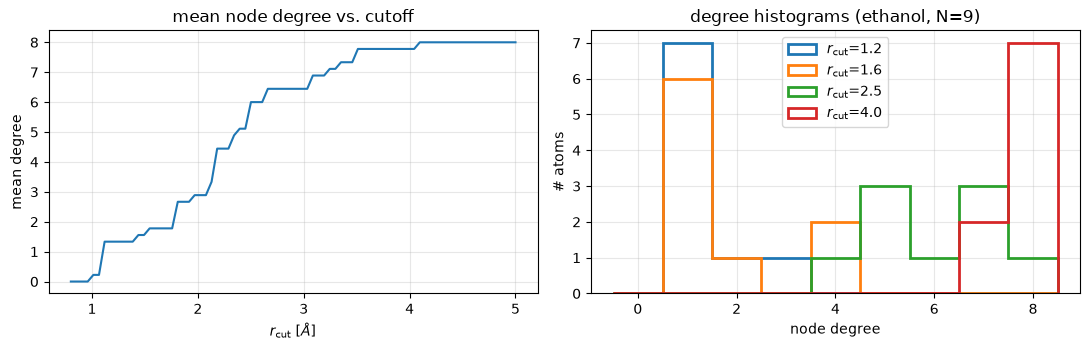

In [7]:
# Calculate the number of atoms
N = len(pos)

# Create a figure with two subplots
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.6))

# Left fig: mean degree as the cutoff sweeps
r_sweep = np.linspace(0.8, 5.0, 80)
mean_deg = [radius_graph(pos, rc).shape[1] / N for rc in r_sweep]
axL.plot(r_sweep, mean_deg)
axL.set_xlabel(r"$r_\mathrm{cut}$ [$\AA$]")
axL.set_ylabel("mean degree")
axL.set_title("mean node degree vs. cutoff")
axL.grid(alpha=0.3)

# Right fig: full degree histograms at the four cutoffs above
for rc in cutoffs:
    ei = radius_graph(pos, rc)
    # receivers -> in-degree
    deg = torch.bincount(ei[0], minlength=N)
    axR.hist(deg.numpy(), bins=np.arange(-0.5, N + 0.5), histtype="step",
             lw=2, label=rf"$r_\mathrm{{cut}}$={rc}")
axR.set_xlabel("node degree")
axR.set_ylabel("# atoms")
axR.set_title("degree histograms (ethanol, N=9)")
axR.legend()
axR.grid(alpha=0.3)
fig.tight_layout()
plt.show()

平均度数呈阶梯状(每遇到一个原子间距离就有一批边接通),一旦环境看起来均匀,它大约按 $r_\mathrm{cut}^3$ 增长。对乙醇,它在 $N-1 = 8$ 处饱和。这个阶梯也是一个警示:**由硬截断构建的量会随原子移动而不连续跳变**。这是第 05b 课的核心问题。

<details><summary>English</summary>

The mean degree is a staircase (edges switch on at each interatomic distance)
that grows roughly like $r_\mathrm{cut}^3$ once the environment looks
homogeneous. For ethanol, it saturates at $N-1 = 8$. This staircase is also a
warning sign: **quantities built from a hard cutoff can jump discontinuously as
atoms move**. This is the central problem of Lesson 05b.

</details>

## 周期性边界条件

晶体和液体在**周期性盒子**中模拟:矩阵 $C \in \mathbb{R}^{3\times 3}$,其行 $\vec a_1, \vec a_2, \vec a_3$ 为晶格矢量。真实体系包含原子 $j$ *及其所有周期镜像*

$$
\vec r_j + \vec S \, C, \qquad \vec S = (n_1, n_2, n_3) \in \mathbb{Z}^3 .
$$

因此,一条边可以把 $i$ 连接到 $j$ 的某个**镜像**,其位移向量需要镜像偏移:

$$
\boxed{\;\vec r_{ij,\vec S} \;=\; \vec r_j + \vec S\, C - \vec r_i\;}
$$

两个后果会让每个初学者的第一次实现栽跟头:

1. **仅有 `edge_index` 是有歧义的。** 同一对 $(i, j)$ 可以通过*多个*镜像(不同的 $\vec S$)相连:甚至 $i = j$(一个原子与自身的镜像成键!)。因此周期性图必须为每条边存储 `edge_shift`,即 $\vec S$,且模型必须按上式计算 $\vec r_{ij}$,绝不能用 `pos[j] - pos[i]`。
2. **最小镜像一般是不够的。** *最小镜像约定*只保留每对原子最近的镜像,仅当 $r_\mathrm{cut}$ 小于盒子最短高度的一半时才有效。ASE 的 `neighbor_list` 枚举 $r_\mathrm{cut}$ 内的*所有*镜像,因此在小盒子下仍然正确——此时截断球可以绕过盒子,多次看到同一个原子。

一个很好的例子:**原胞 fcc 铜盒只含一个原子**,但每个 Cu 原子在 $a/\sqrt{2}$ 处有 12 个最近邻,它们全是镜像。

<details><summary>English</summary>

## Periodic boundary conditions

Crystals and liquids are simulated in a **periodic cell**: a matrix $C \in
\mathbb{R}^{3\times 3}$ whose rows $\vec a_1, \vec a_2, \vec a_3$ are the
lattice vectors. The real system contains atom $j$ *and all its periodic images*

$$
\vec r_j + \vec S \, C, \qquad \vec S = (n_1, n_2, n_3) \in \mathbb{Z}^3 .
$$

An edge may therefore connect $i$ to an **image** of $j$, and its displacement
vector needs the image offset:

$$
\boxed{\;\vec r_{ij,\vec S} \;=\; \vec r_j + \vec S\, C - \vec r_i\;}
$$

Two consequences that trip up every first implementation:

1. **`edge_index` alone is ambiguous.** The same pair $(i, j)$ can be connected
   through *several* images (different $\vec S$): even $i = j$ (an atom bonds to
   its own image!). So a periodic graph must store the `edge_shift`, $\vec S$,
   per edge, and the model must compute $\vec r_{ij}$ from the formula above,
   never from `pos[j] - pos[i]`.
2. **Minimum image is not enough in general.** The *minimum-image convention*
   keeps only the nearest image of each pair which is only valid when
   $r_\mathrm{cut}$ is less than half the shortest cell height. ASE's
   `neighbor_list` enumerates *all* images within $r_\mathrm{cut}$, so it stays
   correct for small cells, where a cutoff sphere can wrap around the box and
   see the same atom several times.

A good example is a **primitive fcc copper cell contains a single atom**, yet
every Cu atom has 12 nearest neighbors at $a/\sqrt{2}$ all of which are images.

</details>

In [8]:
# Create a primitive cell with exactly ONE atom
cu = bulk("Cu", "fcc", a=3.6)
cell = torch.tensor(cu.cell.array)
print("Primitive fcc cell (rows = lattice vectors):\n", cell.numpy(), "\natoms in cell:", len(cu))

# Naive (non-periodic) graph: a single atom has no neighbors at all
print("Naive radius_graph edges:", radius_graph(torch.tensor(cu.positions), r_cut=2.6).shape[1])

# Periodic graph: ASE returns the receiver i, the sender j, and the image shift S
i_np, j_np, S_np = neighbor_list("ijS", cu, cutoff=2.6)
edge_index = torch.stack([torch.from_numpy(i_np).long(), torch.from_numpy(j_np).long()])
edge_shift = torch.from_numpy(S_np).to(torch.get_default_dtype())
i, j = edge_index

# Boxed formula: r_ij = r_j + S @ cell - r_i
edge_vec = cu.positions[j] + edge_shift.numpy() @ cell.numpy() - cu.positions[i]

# Compute the edge lengths
edge_len = np.linalg.norm(edge_vec, axis=-1)

print(f"Periodic edges: {edge_index.shape[1]}  (fcc coordination number = 12)")
print("All edges are self-edges (i=j=0), distinguished only by the shift S:")
print(edge_shift.to(torch.long).numpy().T)
print(f"Edge lengths: all = {edge_len.mean():.4f} A  (expected a/sqrt(2) = {3.6/np.sqrt(2):.4f} A)")
assert np.allclose(edge_len, 3.6 / np.sqrt(2))

Primitive fcc cell (rows = lattice vectors):
 [[0.  1.8 1.8]
 [1.8 0.  1.8]
 [1.8 1.8 0. ]] 
atoms in cell: 1
Naive radius_graph edges: 0
Periodic edges: 12  (fcc coordination number = 12)
All edges are self-edges (i=j=0), distinguished only by the shift S:
[[ 0  1  0  0  1 -1  1 -1  0  0 -1  0]
 [ 0  0  1 -1 -1  0  0  1  1 -1  0  0]
 [-1 -1 -1  0  0  0  0  0  0  1  1  1]]
Edge lengths: all = 2.5456 A  (expected a/sqrt(2) = 2.5456 A)


这 12 条边每一条都是 $(i, j) = (0, 0)$(打印 `edge_index` 验证!):没有 `edge_shift`,它们就是 12 条零长度自环的副本,模型将*一无所获*。有了偏移,每条边获得指向不同邻近镜像的正确位移。

<details><summary>English</summary>

Every one of the 12 edges is $(i, j) = (0, 0)$ (print `edge_index` to verify!):
without `edge_shift` they would be 12 copies of a zero-length self-loop and the
model would see *nothing*. With the shifts, each edge acquires the correct
displacement to a distinct neighboring image.

</details>

### 盒子选取的无关性

物理学不能依赖于我们画出哪个重复单元。惯用立方 fcc 盒含 4 个原子,但每个原子的近邻数必须仍是 12:

<details><summary>English</summary>

### Cell-choice independence

Physics cannot depend on which repeating unit we draw. The conventional cubic
fcc cell holds 4 atoms while the neighbor count per atom must still be 12:

</details>

In [9]:
# Create a conventional cubic cell: 4 atoms
cu4 = bulk("Cu", "fcc", a=3.6, cubic=True)

# Create the neighbor list
i4, j4, S4 = neighbor_list("ijS", cu4, cutoff=2.6)

# Create the edge index
ei4 = torch.stack([torch.from_numpy(i4).long(), torch.from_numpy(j4).long()])

# Create the edge shift tensor
shift4 = torch.from_numpy(S4).to(torch.get_default_dtype())

# Compute the degree of each atom
deg = torch.bincount(ei4[0], minlength=len(cu4))

# Count the number of edges that are within the home cell (S = 0)
n_zero = int((shift4 == 0).all(dim=1).sum())

print(f"Atoms: {len(cu4)}, edges: {ei4.shape[1]}, degree per atom: {deg.tolist()}")
print(f"Edges within the home cell (S = 0): {n_zero}, crossing the boundary (S != 0): {ei4.shape[1] - n_zero}")

Atoms: 4, edges: 48, degree per atom: [12, 12, 12, 12]
Edges within the home cell (S = 0): 12, crossing the boundary (S != 0): 36


让我们可视化由 $(j, S)$ 重建的中心原子及其 12 个镜像邻居。

<details><summary>English</summary>

Let's visualize the central atom and its 12 image-neighbors reconstructed from $(j, S)$

</details>

In [10]:
# Get the positions of the atoms in the conventional cell
center = torch.tensor(cu.positions[0])
neighbors = torch.tensor(cu.positions)[edge_index[1]] + edge_shift @ cell

# Atom 0 first, then its images, with a spoke drawn to each
shell = torch.cat([center[None, :], neighbors])
spokes = torch.stack([torch.zeros(len(neighbors), dtype=torch.long),
                      torch.arange(1, len(neighbors) + 1)])

# Create the 3D figure and draw the point cloud with edges
fig = scene3d()
draw_point_cloud(shell, fig=fig, edges=spokes,
                 color=["tab:red"] + ["tab:blue"] * len(neighbors))
show3d(fig, legend=False,
       title="fcc Cu: first coordination shell (red: atom 0), built from edge_shift")

<plotly figure: fcc Cu: first coordination shell (red: atom 0), built from edge_shift>

## 总结

本课中,我们学到了:

- 原子体系机器学习常把结构表示为**半径图**:节点对应原子,有向边表示相互作用(如化学键),其中 $\lVert\vec r_j - \vec r_i\rVert < r_\mathrm{cut}$。
- **约定(全课程统一):** 边索引存储在 `edge_index` 对象中,第一行 `edge_index[0]` 对应接收方 $i$,第二行 `edge_index[1]` 对应发送方 $j$。这里 $\vec r_{ij} = \vec r_j - \vec r_i$,消息沿 $j \to i$ 流动。
- 相对向量使平移不变性*在构造上精确成立*。旋转作为干净的 $l{=}1$ 向量作用于 $\vec r_{ij}$,并保持边集不变。
- 截断半径 $r_\mathrm{cut}$ 在连通性与计算开销($\langle\deg\rangle \propto r_\mathrm{cut}^3$)之间权衡。边的接通/断开会导致相互作用不连续的问题,第 05b 课将解决它。
- **周期性边界条件(PBC):** 在 PBC 下,边连接到**周期镜像**。此时需存储 `edge_shift` 张量 $\vec S$,并始终按 $\vec r_{ij} = \vec r_j + \vec S C - \vec r_i$ 计算正确的位移向量。

**下一课:** [第 05b 课](05b_radial_basis_and_cutoffs.ipynb)讨论如何把原始的节点间距离 $|\vec r_{ij}|$ 转换为性质良好的网络特征输入。

<details><summary>English</summary>

## Summary

In this lesson, we have learned:

- Atomistic ML often represents structures as **radius graphs** where nodes
  correspond to atoms and directed edges represent interactions (e.g., bonds)
  where $\lVert\vec r_j - \vec r_i\rVert < r_\mathrm{cut}$.
- **Convention (course-wide):** The edge indices are stored in the `edge_index`
  object where the first row, `edge_index[0]`, corresponds to the receiver $i$,
  and the second row, `edge_index[1]`, corresponds to the sender $j$ Here, $\vec
  r_{ij} = \vec r_j - \vec r_i$ and the messages flow from $j \to i$.
- Relative vectors make translation invariance *exact by construction*.
  Rotations act on $\vec r_{ij}$ as clean $l{=}1$ vectors and leave the edge set
  invariant.
- The cutoff radius, $r_\mathrm{cut}$, trades connectivity with computational
  cost ($\langle\deg\rangle \propto r_\mathrm{cut}^3$). The on/off switching of
  the edges causes the interaction discontinuity problem that Lesson 05b
  resolves.
- **Periodic Boundary Condition (PBC):** Under PBC, the edges connect to
  **periodic images**. Here, one stores the `edge_shift` tensor, $\vec S$, and
  always compute $\vec r_{ij} = \vec r_j + \vec S C - \vec r_i$ to get the
  correct displacement vector. 

**Next:** [Lesson 05b](05b_radial_basis_and_cutoffs.ipynb) discusses the
conversion of raw inter-node distances, $|\vec r_{ij}|$, into well-behaved
network feature inputs.

</details>

## 练习

**1(难度:🌶️):** 对乙醇,找出使半径图保持*连通*(单一分量)的最小截断(精确到 0.1 Å)。是哪条键设定了这个阈值?

<details><summary>解答</summary>

```python
import scipy.sparse as sp
import scipy.sparse.csgraph as csgraph

# Get the positions of the atoms in the conventional cell
for rc in np.arange(0.9, 2.0, 0.1):

    # Create the radius graph
    ei = radius_graph(pos, rc)

    # Convert to a sparse adjacency matrix and count connected components
    A = sp.coo_matrix((np.ones(ei.shape[1]), (ei[0], ei[1])), shape=(N, N))

    # Count the number of connected components
    n_comp, _ = csgraph.connected_components(A)

    # Print the results
    print(f"r_cut={rc:.1f}  components={n_comp}")
```
图在 $r_\mathrm{cut} \geq 1.6\,\text{Å}$ 时连通:C–C 键($\approx 1.51\,\text{Å}$)是最长的键,所以低于它时,两个碳"孤岛"(各自靠较短的 C–H / C–O / O–H 键维系)保持分离。
</details>

**2(难度:🌶️🌶️):** 对*正交*盒子(对角盒子,边长 $L_x, L_y, L_z$)实现最小镜像位移。按课程约定写位移 $\vec r_{ij} = \vec r_j - \vec r_i$,令 $\alpha \in \{x, y, z\}$ 索引其笛卡尔分量,每个分量独立回折:$r_{ij,\alpha} \mapsto r_{ij,\alpha} - L_\alpha \,\mathrm{round}(r_{ij,\alpha} / L_\alpha)$。将该公式应用于惯用立方 Cu 盒(`cu4`),取 $r_\mathrm{cut} = 1.7\,\text{Å} < L/2$,检查你的代码能否复现 ASE `neighbor_list` 的边长。为什么必须 $r_\mathrm{cut} < L/2$?

<details><summary>解答</summary>

```python
# Create the pairwise displacement matrix and apply the minimum image convention
P = torch.tensor(cu4.positions)
L = torch.tensor(np.diag(cu4.cell.array))

# All pairwise r_j - r_i
d = P[None, :, :] - P[:, None, :]

# Apply the minimum image convention
d = d - L * torch.round(d / L)

# Calculate the pairwise distances and find edges within the cutoff
dist = d.norm(dim=-1).fill_diagonal_(np.inf)
ii, jj = (dist < 1.7).nonzero(as_tuple=True)

# Check that the distances match the neighbor_list output from ASE
i_ref, j_ref, S_ref = neighbor_list("ijS", cu4, 1.7)

# Reference edges
ei_ref = torch.stack([torch.from_numpy(i_ref).long(), torch.from_numpy(j_ref).long()])

# Reference shifts
sh_ref = torch.from_numpy(S_ref).to(torch.get_default_dtype())

# Make sure the edges match
assert len(ii) == ei_ref.shape[1]
```

`round` 函数选取*单个最近*的镜像。如果 $r_\mathrm{cut} \geq L/2$,同一邻居可能有两个或更多镜像落在截断范围内,但最小镜像只保留一条边。这样它会静默丢弃那些(本应存在的)相互作用(此处 $L = 3.6\,\text{Å}$,因此 $r_\mathrm{cut}=2.6$ 就已经不安全了)。这正是 ASE 的 `neighbor_list` 函数改为枚举镜像的原因。
</details>

**3(难度:🌶️🌶️):** 假设 $r_\mathrm{cut} = 5\,\text{Å}$,估计 fcc Cu($a=3.6\,\text{Å}$,每 $a^3$ 内 4 个原子)的平均度数。用 ASE 的 `neighbor_list` 验证你的结果。提示:利用平均度数对截断半径的阶梯图。解析上,对数密度为 $\rho$ 的均匀体系,可以写出:$\langle\deg\rangle = \tfrac{4}{3}\pi r_\mathrm{cut}^3 \rho$。

<details><summary>解答</summary>

$\rho = N/V = 4/3.6^3 = 0.0857\,\text{Å}^{-3}$,

于是,

$\langle\deg\rangle \approx \tfrac{4}{3}\pi \cdot (5)^3 \cdot 0.0857 \approx 44.9$。

用 ASE 的 `neighbor_list` 函数可以验证这个估计:

```python
# Get the neighbor list for r_cut = 5.0 Å
i5, j5, _ = neighbor_list("ijS", cu, cutoff=5.0)

# Create the edge index tensor
ei = torch.stack([torch.from_numpy(i5).long(), torch.from_numpy(j5).long()])

# Calculate the mean degree
# 42 -- close; the discrete shells make it slightly lumpy
print(ei.shape[1] / len(cu))
```
</details>

<details><summary>English</summary>

## Exercises

**1 (Difficulty: 🌶️):** For ethanol, find the smallest cutoff (down to 0.1 Å) at which the radius
graph remains *connected* (one component). Which bond sets the threshold?

<details><summary>Solution</summary>

```python
import scipy.sparse as sp
import scipy.sparse.csgraph as csgraph

# Get the positions of the atoms in the conventional cell
for rc in np.arange(0.9, 2.0, 0.1):

    # Create the radius graph
    ei = radius_graph(pos, rc)

    # Convert to a sparse adjacency matrix and count connected components
    A = sp.coo_matrix((np.ones(ei.shape[1]), (ei[0], ei[1])), shape=(N, N))

    # Count the number of connected components
    n_comp, _ = csgraph.connected_components(A)

    # Print the results
    print(f"r_cut={rc:.1f}  components={n_comp}")
```
The graph becomes connected at $r_\mathrm{cut} \geq 1.6\,\text{Å}$: the C–C bond
($\approx 1.51\,\text{Å}$) is the longest bond, so below it, the two carbon
"islands" (each held together by shorter C–H / C–O / O–H bonds) stay separate.
</details>

**2 (Difficulty: 🌶️🌶️):** Implement the minimum-image displacement for an *orthorhombic* box
(diagonal cell, lengths $L_x, L_y, L_z$). Writing the displacement in the course
convention, $\vec r_{ij} = \vec r_j - \vec r_i$, and letting $\alpha \in \{x, y,
z\}$ index its Cartesian components, each component wraps independently:
$r_{ij,\alpha} \mapsto r_{ij,\alpha} - L_\alpha \,\mathrm{round}(r_{ij,\alpha} /
L_\alpha)$. Apply this formula to the conventional cubic Cu cell (`cu4`) with
$r_\mathrm{cut} = 1.7\,\text{Å} < L/2$ and check your code to see if it
reproduces the `neighbor_list` edge lengths from ASE. Why must $r_\mathrm{cut} <
L/2$?

<details><summary>Solution</summary>

```python
# Create the pairwise displacement matrix and apply the minimum image convention
P = torch.tensor(cu4.positions)
L = torch.tensor(np.diag(cu4.cell.array))

# All pairwise r_j - r_i
d = P[None, :, :] - P[:, None, :]

# Apply the minimum image convention
d = d - L * torch.round(d / L)

# Calculate the pairwise distances and find edges within the cutoff
dist = d.norm(dim=-1).fill_diagonal_(np.inf)
ii, jj = (dist < 1.7).nonzero(as_tuple=True)

# Check that the distances match the neighbor_list output from ASE
i_ref, j_ref, S_ref = neighbor_list("ijS", cu4, 1.7)

# Reference edges
ei_ref = torch.stack([torch.from_numpy(i_ref).long(), torch.from_numpy(j_ref).long()])

# Reference shifts
sh_ref = torch.from_numpy(S_ref).to(torch.get_default_dtype())

# Make sure the edges match
assert len(ii) == ei_ref.shape[1]
```

The `round` function picks the *single nearest* image. If $r_\mathrm{cut} \geq
L/2$, an atom can be within the cutoff of *two or more* images of the same
neighbor, but minimum image should only keep one edge. As such, it will silently
drop the illigal interactions (here, $L = 3.6\,\text{Å}$, so
$r_\mathrm{cut}=2.6$ would already be unsafe). That is why the `neighbor_list`
function in ASE enumerates images instead.
</details>

**3 (Difficulty: 🌶️🌶️):** Assuming $r_\mathrm{cut} = 5\,\text{Å}$, estimate the mean degree for fcc
Cu ($a=3.6\,\text{Å}$, 4 atoms per $a^3$). Verify your result with that of
`neighbor_list` from ASE. Hint: Use the staircase plot of mean degree vs. cutoff
radius. Analytically, for a homogeneous system of number density $\rho$,
one can write: $\langle\deg\rangle = \tfrac{4}{3}\pi r_\mathrm{cut}^3 \rho$. 

<details><summary>Solution</summary>

$\rho = N/V = 4/3.6^3 = 0.0857\,\text{Å}^{-3}$,

So, 

$\langle\deg\rangle \approx \tfrac{4}{3}\pi \cdot (5)^3 \cdot 0.0857 \approx 44.9$.

Using ASE's `neighbor_list` function, we can verify this estimate:

```python
# Get the neighbor list for r_cut = 5.0 Å
i5, j5, _ = neighbor_list("ijS", cu, cutoff=5.0)

# Create the edge index tensor
ei = torch.stack([torch.from_numpy(i5).long(), torch.from_numpy(j5).long()])

# Calculate the mean degree
# 42 -- close; the discrete shells make it slightly lumpy
print(ei.shape[1] / len(cu))
```
</details>

</details>

## 参考文献

- [Battaglia et al., *Relational inductive biases and graph networks* arXiv.1806.01261 (2018)](https://arxiv.org/pdf/1806.01261)
- [ASE documentation](https://ase.gitlab.io/ase/ase/neighborlist.html#ase.neighborlist.neighbor_list) 中关于 `ase.neighborlist.neighbor_list` 的部分

<details><summary>English</summary>

## References

- [Battaglia et al., *Relational inductive biases and graph networks* arXiv.1806.01261 (2018)](https://arxiv.org/pdf/1806.01261)
- [ASE documentation](https://ase.gitlab.io/ase/ase/neighborlist.html#ase.neighborlist.neighbor_list) for `ase.neighborlist.neighbor_list`

</details>